In [3]:
import pandas as pd

pairs = [
    ("good morning", "qayirly tan"),
    ("good night", "qayirly tün"),
    ("hello", "sälem"),
    ("goodbye", "sau bol"),
    ("thank you", "raqmet"),
    ("you are welcome", "oqasy joq"),
    ("please", "ötinemin"),
    ("sorry", "keshiriniz"),
    ("yes", "iä"),
    ("no", "joq"),
    ("how are you", "qalynyz qalai"),
    ("i am fine", "men jaqsymyn"),
    ("what is your name", "atynyz kim"),
    ("my name is", "mening atym"),
    ("where is the station", "vokzal qayda"),
    ("where is the airport", "äuejai qayda"),
    ("where is the hotel", "qonaqüi qayda"),
    ("where is the bus stop", "ayaldama qayda"),
    ("i need help", "mağan kömek kerek"),
    ("call the doctor", "däriger shaqyryñyz"),
    ("i am lost", "men adasyp qaldym"),
    ("how much is this", "bul qanşa turady"),
    ("too expensive", "tym qymbat"),
    ("cheap ticket", "arzan bilet"),
    ("book a ticket", "bilet bronda"),
    ("buy a ticket", "bilet satyp al"),
    ("open the door", "esikti ash"),
    ("close the window", "terezeni jap"),
    ("turn on the light", "jaryqty jaq"),
    ("turn off the light", "jaryqty öshir"),
    ("i love this movie", "mağan bul film unaydy"),
    ("this movie is bad", "bul film jaman"),
    ("this movie is good", "bul film jaqsı"),
    ("not good", "jaqsı emes"),
    ("very good", "öte jaqsı"),
    ("i am hungry", "meniń qarnym ash"),
    ("i am tired", "men şarşadım"),
    ("i am ready", "men dayynmyn"),
    ("let us go", "jüreyik"),
    ("come here", "munda kel"),
    ("sit down", "otyr"),
    ("stand up", "tur"),
    ("speak slowly", "bayaū söyleñiz"),
    ("repeat please", "qaita aytyñızşı")
]

pairs_df = pd.DataFrame(pairs, columns=["english", "kazakh"])
print("Total phrase pairs:", len(pairs_df))
pairs_df.head(10)

Total phrase pairs: 44


,english,kazakh
0,good morning,qayirly tan
1,good night,qayirly tün
2,hello,sälem
3,goodbye,sau bol
4,thank you,raqmet
5,you are welcome,oqasy joq
6,please,ötinemin
7,sorry,keshiriniz
8,yes,iä
9,no,joq


Example after adding special tokens:
Source: ['<sos>', 'good', 'morning', '<eos>']
Target: ['<sos>', 'qayirly', 'tan', '<eos>']


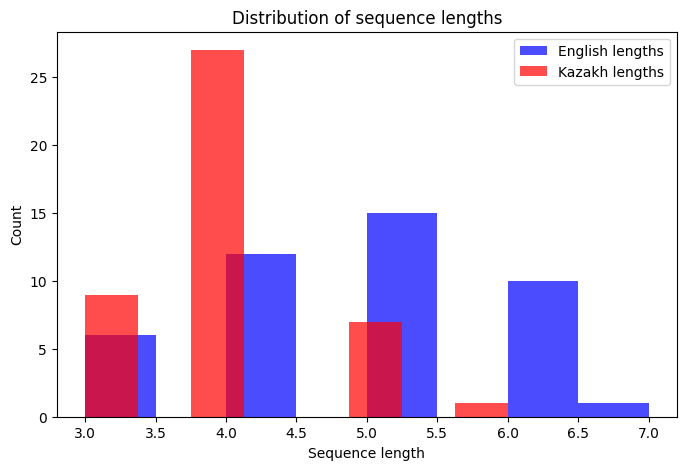

Average source length: 4.73
Average target length: 4.0


In [6]:
import matplotlib.pyplot as plt
import numpy as np

src_tokens = []
tgt_tokens = []

for src, tgt in pairs:
    src_seq = ["<sos>"] + src.lower().split() + ["<eos>"]
    tgt_seq = ["<sos>"] + tgt.lower().split() + ["<eos>"]
    src_tokens.append(src_seq)
    tgt_tokens.append(tgt_seq)

print("Example after adding special tokens:")
print("Source:", src_tokens[0])
print("Target:", tgt_tokens[0])

src_lens = [len(x) for x in src_tokens]
tgt_lens = [len(x) for x in tgt_tokens]

plt.figure(figsize=(8, 5))
plt.hist(src_lens, bins=8, alpha=0.7, label="English lengths" ,color='blue')
plt.hist(tgt_lens, bins=8, alpha=0.7, label="Kazakh lengths" ,color='red')
plt.xlabel("Sequence length")
plt.ylabel("Count")
plt.title("Distribution of sequence lengths")
plt.legend()
plt.show()

print("Average source length:", round(np.mean(src_lens), 2))
print("Average target length:", round(np.mean(tgt_lens), 2))

In [7]:
max_len = max(max(src_lens), max(tgt_lens))

def pad_sequence(seq, max_len):
    return seq + [""] * (max_len - len(seq))

padded_src = [pad_sequence(seq, max_len) for seq in src_tokens]
padded_tgt = [pad_sequence(seq, max_len) for seq in tgt_tokens]

print("One padded batch example (first 5 source sequences):\n")
for i in range(5):
    print(f"{i+1}.", padded_src[i])

print("\nWhy padding is needed:")
print("Neural networks usually process batches with the same tensor shape.")
print("Sentences have different lengths, so we pad shorter ones with  to make them equal in length.")
print()
print("Why averaging source-word vectors is not enough for translation:")
print("A single average vector loses word order and cannot generate the target sentence token by token.")
print("Translation needs a model that remembers sequence order and produces output step by step.")


One padded batch example (first 5 source sequences):

1. ['<sos>', 'good', 'morning', '<eos>', '', '', '']
2. ['<sos>', 'good', 'night', '<eos>', '', '', '']
3. ['<sos>', 'hello', '<eos>', '', '', '', '']
4. ['<sos>', 'goodbye', '<eos>', '', '', '', '']
5. ['<sos>', 'thank', 'you', '<eos>', '', '', '']

Why padding is needed:
Neural networks usually process batches with the same tensor shape.
Sentences have different lengths, so we pad shorter ones with  to make them equal in length.

Why averaging source-word vectors is not enough for translation:
A single average vector loses word order and cannot generate the target sentence token by token.
Translation needs a model that remembers sequence order and produces output step by step.
